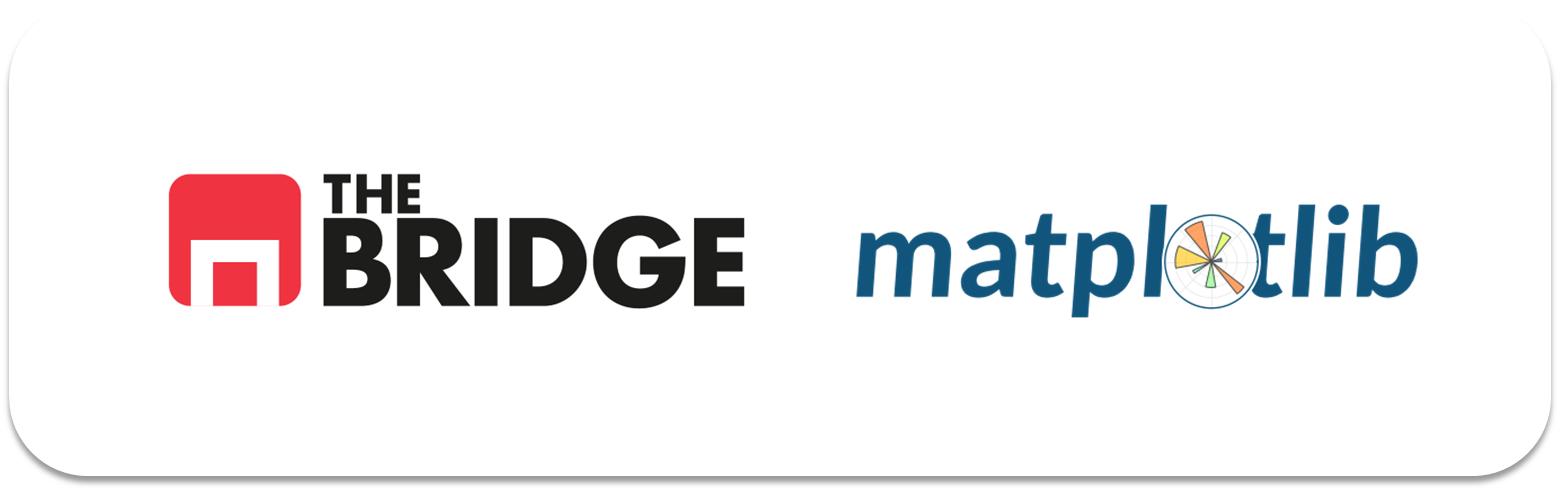


# Visualización con Matplotlib: Introducción


Vamos a echar un vistazo con algo de detalle al [paquete Matplotlib](https://matplotlib.org/) que es una biblioteca de visualización de datos **multiplataforma** construida sobre *arrays* de **NumPy**, y diseñada para trabajar con el amplio conjunto de herramientas de **SciPy**.   

Fue concebida por John Hunter en 2002, originalmente como un parche para IPython que permitiera trazar gráficos interactivos al estilo MATLAB a través de [gnuplot](http://www.gnuplot.info/) desde la línea de comandos de IPython.  

Una de las características más importantes de Matplotlib es su **capacidad para funcionar bien con muchos sistemas operativos y backends gráficos**. Aunque herramientas más nuevas como ggplot y ggvis en el lenguaje R, junto con kits de herramientas de visualización web basados en D3js y HTML5 canvas, o incluso librerías python como seaborn o plotly a menudo hacen que Matplotlib parezca un poco anticuado, su fortaleza como motor gráfico probado y multiplataforma no puede ser ignorada.


### Consejos generales de Matplotlib

Antes de sumergirnos en los detalles de la creación de visualizaciones con Matplotlib en las siguientes sesiones, hay algunas cosas útiles que deberías saber sobre el uso del paquete.



#### Importando Matplotlib

Al igual que usamos el atajo ``np`` para NumPy y el atajo ``pd`` para Pandas, usaremos algunos atajos estándar para las importaciones de Matplotlib:
```

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


El interfaz ``plt`` (alias del módulo pyplot una versión más estilo python que el propio paquete original) es lo que usaremos con más frecuencia, así que quedate con la segunda línea más que con la primera.


#### Configuración de estilos

Utilizaremos la directiva ``plt.style`` para elegir estilos estéticos apropiados para nuestras figuras. Aquí estableceremos el estilo ``classic``, que garantiza que los gráficos que creamos utilicen el estilo clásico de Matplotlib.

In [2]:
plt.style.use('classic')

In [3]:
# Que estilos hay por defecto
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

### Cómo mostrar los gráficos

Una visualización que no puedes ver no será de mucha utilidad, pero la forma en que podemos mostrar las gráficas de Matplotlib depende del contexto.  

En general, **los tres contextos aplicables son usar Matplotlib en un script, en un terminal IPython o en un cuaderno IPython.** Pero nosotros sólo lo vamos a ver en el contexto de los notebooks. Si quieres saber más de como puedes usar matplotlib en scripts, [aqui](https://matplotlib.org/stable/tutorials/pyplot.html) tienes una referencia, y [aqui](https://ipython.readthedocs.io/en/stable/interactive/plotting.html#id1) tienes otra para el caso del interactive python (IPython).




Auque para mostrar gráficos no necesitamos hacer nada en especial, si queremos darle algo de interactividad a los mismos podemos utilizar el comando ``%matplotlib`` con dos posibles opciones:

- ``%matplotlib notebook`` generará gráficos *interactivos* incrustados dentro del cuaderno
- ``%matplotlib inline`` generará imágenes *estáticas* de tu gráfico incrustadas en el cuaderno (es decir que los conservas aunque cierres el notebook)


In [4]:
%matplotlib inline

Después de ejecutar este comando (solo es necesario hacerlo una vez por kernel/sesión), cualquier celda dentro del cuaderno que cree un gráfico incrustará una imagen PNG del gráfico resultante:

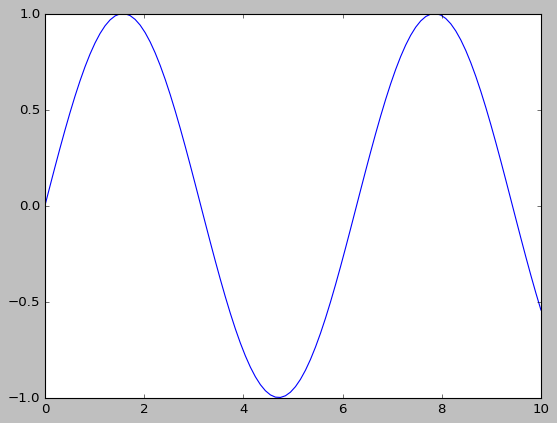

In [ ]:
x = np.linspace(0, 10, 100)
y = np.sin(x)

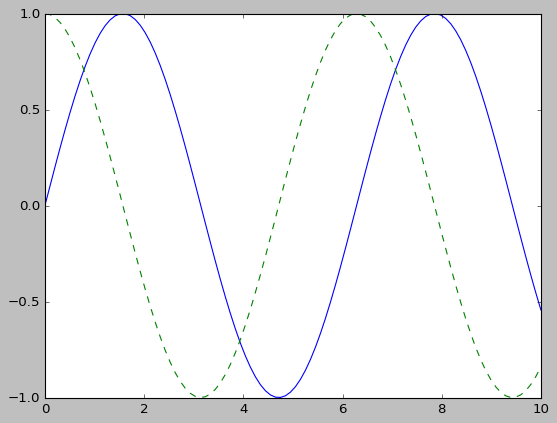

In [9]:
fig = plt.figure()
plt.plot(x, y, "-")
plt.plot(x, np.cos(x), "--")
fig.savefig("seno_coseno.png")


### Guardar figuras en archivo

Una característica útil de Matplotlib es la capacidad de guardar figuras en una amplia variedad de formatos.
Guardar una figura se puede hacer usando el método ``savefig()``.
Por ejemplo, para guardar la figura anterior como un archivo PNG, puedes ejecutar esto:


Ahora tenemos un archivo llamado ``my_figure.png`` en el directorio de trabajo "./img"

Para confirmar que contiene lo que pensamos que contiene, usemos el objeto IPython ``Image`` para mostrar el contenido de este archivo:

En ``savefig()``, el formato de archivo se infiere de la extensión del nombre de archivo dado.


### Dos interfaces por el precio de uno

Una característica potencialmente confusa de Matplotlib es sus dos interfaces: una conveniente interfaz basada en el estado al estilo de MATLAB, y una interfaz orientada a objetos más poderosa. Destacaremos rápidamente las diferencias entre las dos aquí.
```


#### Interfaz al estilo MATLAB (Como lo verás en muchos sitios)

**Matplotlib fue originalmente escrito como una alternativa de Python para usuarios de MATLAB**, y gran parte de su sintaxis refleja ese hecho.
Las herramientas al estilo MATLAB están contenidas en la interfaz pyplot (``plt``).


In [ ]:
fig = plt.figure()

plt.subplot(2, 2, 1) # filas, columnas, indice
plt.plot(x, np.sin(x))


plt.subplot(2, 2, 2) # filas, columnas, indice
plt.plot(x, np.cos(x));


plt.subplot(2, 2, 3) # filas, columnas, indice
plt.plot(x, 2*x*x/100);

plt.subplot(2, 2, 1) # filas, columnas, indice
plt.plot(x, 2*x*x/100);


Es importante tener en cuenta que esta interfaz es *stateful*: lleva un registro de la **"figura" y ejes "actuales", en los cuales se aplican todos los comandos de ``plt``.**
Puedes obtener una referencia a estos utilizando las rutinas ``plt.gcf()`` (obtener figura actual) y ``plt.gca()`` (obtener ejes actuales).

Si bien esta forma de actuar de la interfaz es rápida y conveniente para gráficos simples, es fácil encontrarse con problemas.
Por ejemplo, una vez que se crea el segundo panel, ¿cómo podemos retroceder y agregar algo al primero?
Esto es posible dentro de la interfaz de estilo MATLAB, pero es un poco engorroso.
Afortunadamente, hay una mejor manera.

In [ ]:
plt.subplot(2,2,1)
plt.plot(x,np.full(shape=(100,),fill_value= 1))

In [ ]:
display(fig)


#### Interfaz orientada a objetos

La interfaz orientada a objetos está disponible para situaciones más complicadas y cuando se desea tener más control sobre la figura.
En lugar de depender de alguna noción de una figura o ejes "activos", en la interfaz orientada a objetos las funciones de trazado son *métodos* de objetos ``Figure`` y ``Axes`` explícitos.
Para volver a crear el gráfico anterior usando este estilo de trazado, podrías hacer lo siguiente:


In [ ]:
# First create a grid of plots
# ax will be an array of two Axes objects
fig, ax = plt.subplots(2,2)
ax[0,0].plot(x, np.sin(x))
ax[1,1].plot(x, np.cos(x))
ax[1,1].plot(x, 0*x)
ax[0,1].plot(x, x)


In [ ]:
ax[0,1].plot(x, x-3)

In [ ]:
display(fig)

In [ ]:
fig.savefig('img/prueba.png')

In [ ]:
Image('img/prueba.png')


Para gráficos más simples, la elección del estilo a utilizar es en gran medida una **cuestión de preferencia, pero el enfoque orientado a objetos puede convertirse en una necesidad a medida que los gráficos se vuelven más complicados.**  

A lo largo de esta unidad, alternaremos entre las interfaces de estilo MATLAB y orientado a objetos, dependiendo de lo que sea más conveniente.  ç

En la mayoría de los casos, la diferencia es tan pequeña como cambiar ``plt.plot()`` a ``ax.plot()``, pero hay algunas cosas a tener en cuenta que destacaremos a medida que surjan en las siguientes sesiones.
